In [1]:
import copy

import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from its.search import InverseTransformationSearch
from search.parallel_gradient import ParallelGradientDescent
from utils.affine_transforms_old import AffineTransformation2D
from utils.sampling import BatchNegativeSampler

#torch.cuda.is_available = lambda: False
#device = torch.device("cpu")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#look for experiment files in parents
import os

path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)

experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")
dataset = "tu_berlin"

default_architecutre_mapping = {
    "mnist":"resnet_small",
    "bigger_mnist":"resnet_small",
    "emnist": "extended_resnet_small",
    "bigger_emnist":"bigger_extended_resnet_small",
    "coil100":"coil_resnet_small",
    "tu_berlin":"bi_lstm",
    "modelnet10":"pointnetplus",
}



architecture = default_architecutre_mapping[dataset]
budget = None

In [2]:
from experiment_thesis.dataset_preperation.get_dataset import get_dataset_info,get_dataset

dataset_info = get_dataset_info(dataset)

dataset_dict = get_dataset(dataset_info,path=experiment_files_path_data, batch_size=dataset_info.batch_size)
transform_name = dataset_info.transform_seq_name

Loaded cached TU-Berlin dataset (max_len=200, interpolation_points=2)


In [3]:


dataset_dict.keys()
dataset_train = dataset_dict['train_dataset']
dataset_val = dataset_dict['val_dataset']
dataset_test = dataset_dict['test_dataset']
train_loader = dataset_dict['train_loader']
val_loader = dataset_dict['val_loader']
test_loader = dataset_dict['test_loader']
n_classes = dataset_info.num_classes
train_loader_transformed = dataset_dict['train_loader_transformed']
val_loader_transformed = dataset_dict['val_loader_transformed']
test_loader_transformed = dataset_dict['test_loader_transformed']
train_loader_no_shuffle = dataset_dict['train_loader_no_shuffle']

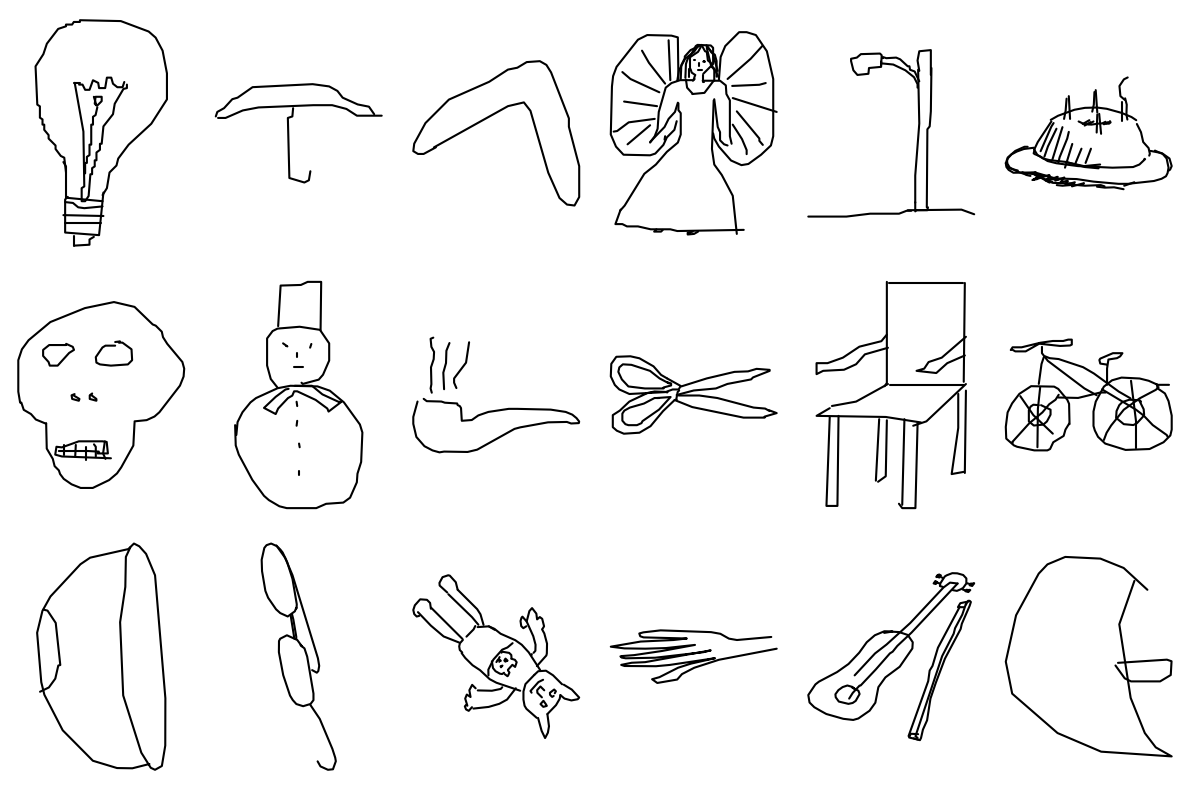

In [4]:
x = next(iter(test_loader_transformed))[0]

batch_size = next(iter(train_loader))[0].shape[0]

from utils.eval.vis import vis_dataset

vis_dataset(train_loader, val_loader, test_loader_transformed)
from experiment_thesis.main import train_and_get_model, train_or_load_energy_model
from experiment_thesis.dataset_preperation.basic_networks import get_network
from utils.eval.main_model import evaluate_base_model

model_dir_path = os.path.join(current_path, "experiment_files", "models")
embedding_cache_path = os.path.join(current_path, "experiment_files", "embedding_cache")
# Add results dir and helper for save paths
results_dir_path = os.path.join(current_path, "experiment_files", "results", dataset, architecture,
                                "comparison_unsupervised")
os.makedirs(results_dir_path, exist_ok=True)


def savepath(label: str) -> str:
    safe = "".join(c if c.isalnum() or c in "-_." else "_" for c in label)
    return os.path.join(results_dir_path, transform_name, f"{safe}.json")

In [5]:
model = get_network(dataset_info,architecture, num_classes=n_classes).to(device)
modelname = f"{dataset}_{architecture}"
cache_name_train= f"{dataset}_{architecture}_embedding_cache_train"

train_and_get_model(model,model_dir_path,modelname, train_loader, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs,
        "precision": "16-mixed",
},load_if_exists=True)



Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\tu_berlin_bi_lstm.safetensors


(BILSTMSKETCHClassifier(
   (preprocess): NormalizeToRangeBatched()
   (rnn): LSTM(3, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
   (attention): Linear(in_features=512, out_features=1, bias=False)
   (attn_dropout): Dropout(p=0.2, inplace=False)
   (augmentation): StrokeAugment()
   (classifier): Sequential(
     (0): Linear(in_features=512, out_features=512, bias=True)
     (1): GELU(approximate='none')
     (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
     (3): Dropout(p=0.5, inplace=False)
     (4): Linear(in_features=512, out_features=250, bias=True)
   )
 ),
 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\experiment_files\\models\\tu_berlin_bi_lstm.safetensors')

In [6]:
model.eval().to(device)

BILSTMSKETCHClassifier(
  (preprocess): NormalizeToRangeBatched()
  (rnn): LSTM(3, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (attention): Linear(in_features=512, out_features=1, bias=False)
  (attn_dropout): Dropout(p=0.2, inplace=False)
  (augmentation): StrokeAugment()
  (classifier): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=250, bias=True)
  )
)

In [7]:
#check main model
res = evaluate_base_model(model, test_loader_transformed, device)
print(res)
res = evaluate_base_model(model, test_loader, device)
print(res)

{'accuracy': 0.0820000022649765, 'f2_macro': 0.07489944994449615, 'f2_micro': 0.0820000022649765, 'f2_weighted': 0.07477008551359177}


{'accuracy': 0.515500009059906, 'f2_macro': 0.4997326731681824, 'f2_micro': 0.515500009059906, 'f2_weighted': 0.509273111820221}


In [8]:
is_image_data = len(dataset_info.input_size) == 3 and dataset_info.input_size[0] in [1, 3]





from utils.transforms.apply import grid_resample
from experiment_thesis.dataset_preperation.transformation import get_transformation_sequence_images

transform_seq = get_transformation_sequence_images(
    name=dataset_info.transform_seq_name,
    resample_method=dataset_info.resample_method,
    init_method="sobol"
).to(device)
from utils.replacer import replace_rotation_transforms_2vec

if dataset == "modelnet10":
    transform_seq = replace_rotation_transforms_2vec(transform_seq)

In [9]:
print(transform_seq.transformations)

[<utils.transforms.rotation.Rotation2D object at 0x0000013C0FF81EA0>, <utils.transforms.shear.DirectedShear object at 0x0000013C114DB040>, <utils.transforms.shear.DirectedShear object at 0x0000013C114DB0A0>, <utils.transforms.scale.DirectedScale object at 0x0000013C114DA1A0>, <utils.transforms.scale.DirectedScale object at 0x0000013C114DA440>]


In [10]:
from experiment_thesis.dataset_preperation.basic_networks import make_deterministic
make_deterministic(model)



In [11]:
from experiment_thesis.dataset_preperation.get_dataset import get_layer_embedding_cache_config,create_layer_embedding_cache
cache_config = get_layer_embedding_cache_config(dataset, architecture,transform_name=None,dataset_info=dataset_info)
train_cache =create_layer_embedding_cache(model, train_loader_no_shuffle,cache_config, embedding_cache_path, device=device)


In [12]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [13]:
from experiment_thesis.ood import base_prepare

base_prepare.OOD_PARAM_SAMPLERS.keys()

dict_keys(['energy', 'energy_ts', 'max_logit', 'entropy', 'max_softmax', 'differentiable_max_softmax', 'adjusted_entropy', 'Max Logit', 'MSP', 'cross_entropy', 'ash', 'gradnorm', 'laplace_prob', 'laplace_energy', 'laplace_variance', 'laplace_mutual_information', 'laplace_entropy_plus_mi', 'laplace_entropy', 'laplace_weighted', 'laplace_mi', 'laplace_best_criterion', 'laplace_entropy_gridsearch', 'laplace_energy_multi', 'mc_dropout_prob', 'mc_dropout_variance', 'mc_dropout_mi', 'mc_dropout_energy', 'mc_dropout_last_layer_prob', 'mc_dropout_last_layer_variance', 'mc_dropout_last_layer_mi', 'mc_dropout_last_layer_energy', 'mc_batchnorm_prob', 'mc_batchnorm_variance', 'mc_batchnorm_mi', 'mc_batchnorm_energy', 'mc_dropout_best_criterion', 'mc_batchnorm_best_criterion', 'mc_dropout_last_layer_best_criterion', 'react', 'react_all', 'dice', 'gaussian', 'gmm', 'gram', 'kde', 'kl_matching', 'faiss_knn', 'faiss_per_class_knn', 'knn', 'per_class_knn', 'knn_trap', 'per_class_knn_trap', 'knn_mixed',

In [14]:
detectors = ["knn","per_class_knn", "knn_mixed","per_class_knn_mixed","vim","react","dice","ash","she","laplace_energy","laplace_weighted","trust_score","openmax","mahalanobis","rmd","class_prototype","react_all","energy","per_class_prototype","prototype_multi", "laplace_entropy","adjusted_entropy","laplace_energy_multi"]
#dont do kde to expensive, and not better.
#global protoype makes no sense over class based protoype
# lof fit is to slow, gmm is even slower or fails due to size
# gram runs out of main memory,

detectors_parameterless = ["energy_ts","entropy","kl_matching","laplace_entropy_gridsearch","MSP","Max Logit"]
detectors = detectors + detectors_parameterless
from experiment_thesis.dataset_preperation.basic_networks import FlexibleResNet
if not isinstance(model,FlexibleResNet):
    #remove ash and react_all as they only work with resnets
    detectors.remove("ash")
    detectors.remove("react_all")
    if "react" not in detectors:
        detectors.append("react")
    detectors.append("ash_last")



In [15]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [16]:
model

BILSTMSKETCHClassifier(
  (preprocess): NormalizeToRangeBatched()
  (rnn): LSTM(3, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (attention): Linear(in_features=512, out_features=1, bias=False)
  (attn_dropout): Dropout(p=0.2, inplace=False)
  (augmentation): StrokeAugment()
  (classifier): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=250, bias=True)
  )
)

In [17]:
from typing import Optional, Any
import os
import json
from itertools import chain
import torch
import optuna
from utils.eval.ood_performance import evaluate_confidence_module, save_eval_results

def load_or_run_evaluate_ood_metric(
    confidence_module,
    id_loader,
    ood_loader,
    save_path: Optional[str] = None,
    device: torch.device | str = "cuda",
    show_progress: bool = True,
    overwrite: bool = False,
    base_model: Optional[Any] = None,
    mode: str = "label",
):
    """
    Evaluate ID + OOD loaders after forcing OOD labels to be negative.
    Removed the previous condition check.
    """

    def relabeled_ood_loader(loader):
        for x, y in loader:
            # force OOD labels to y < 0
            yield x, torch.full_like(y, -1)

    # relabel OOD loader
    ood_loader = relabeled_ood_loader(ood_loader)

    # If no cache path, evaluate directly
    if not save_path:
        combined_loader = chain(id_loader, ood_loader)
        return evaluate_confidence_module(
            confidence_module=confidence_module,
            data_loader=combined_loader,
            mode=mode,
            base_model=base_model,
            device=device,
            show_progress=show_progress,
        )

    # Load cached result if exists and not overwriting
    if not overwrite and os.path.exists(save_path):
        try:
            with open(save_path, "r", encoding="utf-8") as f:
                return json.load(f)
        except Exception:
            pass  # corrupted → recompute

    # Evaluate fresh
    combined_loader = chain(id_loader, ood_loader)
    result = evaluate_confidence_module(
        confidence_module=confidence_module,
        data_loader=combined_loader,
        mode=mode,
        base_model=base_model,
        device=device,
        show_progress=show_progress,
    )

    save_eval_results(save_path, result)
    return result


In [18]:
import os
import json
import torch
import gc
import numpy as np
import copy
from torch.utils.data import DataLoader, Subset
import optuna

from experiment_thesis.ood.base_prepare import (
    run_ood_study,
    get_default_ood_params,
    get_best_ood_params_from_study,
    create_ood_problem,
)
from utils.eval.ood_performance import load_or_run_evaluate_confidence_and_search
from search.shgo import SHGO

search_objective = "search"

n_trials_search = 120
n_trials_search_refine = 15
eval_repeats = 5
if dataset in ["tu_berlin","modelnet10","coil100"]:
    eval_repeats = 10
show_progress = True
top_k = 3

#this here forces the main experiment to not load models from smaller loaders
#as this can lead to overfitting to small loaders which is not desired.
#only the loader on stage 2 the full val set should be stored and reused for final eval(so that they are the same as the best selected model)
allow_loading_models_from_smaller_loaders = False



rng = np.random.default_rng(seed=42)

# Determine report_fraction based on dataset
if dataset in ["mnist", "bigger_mnist", "emnist", "bigger_emnist"]:
    report_fraction_stage1 = 0.25
else:
    report_fraction_stage1 = 0.5

transform_seq_arg = transform_seq

optimizer = SHGO(initial_samples=46, local_runs=2, local_max_steps=3,local_opt_kwargs={"lr":0.1})
if dataset == "tu_berlin":
    optimizer = SHGO(initial_samples=60,local_runs=1,local_max_steps=0,local_opt_kwargs={"lr":0.1})

optimizer_search_eval = optimizer

base_results_dir = os.path.join(
    current_path,
    "experiment_files",
    "results",
    "comparison_unsupervised",
    str(dataset),
    str(architecture),
    getattr(dataset_info, "transform_seq_name", "default"),
)
os.makedirs(base_results_dir, exist_ok=True)

model.eval().to(device)

# ---------------- Prepare validation subsets ----------------
val_dataset = val_loader_transformed.dataset
n_samples = len(val_dataset)
subset_size = n_samples // 6

all_indices = rng.permutation(n_samples)

subset_indices_1 = all_indices[:subset_size]
subset_indices_2 = all_indices[subset_size: 2 * subset_size]
subset_indices_3 = all_indices[2 * subset_size: 3 * subset_size]

val_subset_1 = Subset(val_dataset, subset_indices_1)
val_subset_2 = Subset(val_dataset, subset_indices_2)
val_subset_3 = Subset(val_dataset, subset_indices_3)

val_loader_small_1 = DataLoader(
    val_subset_1,
    batch_size=dataset_info.batch_size,
    shuffle=False,
    num_workers=val_loader_transformed.num_workers,
    pin_memory=True,
    persistent_workers=val_loader_transformed.persistent_workers
)
val_loader_small_2 = DataLoader(
    val_subset_2,
    batch_size=dataset_info.batch_size,
    shuffle=False,
    num_workers=val_loader_transformed.num_workers,
    pin_memory=True,
    persistent_workers=val_loader_transformed.persistent_workers
)
val_loader_small_3 = DataLoader(
    val_subset_3,
    batch_size=dataset_info.batch_size,
    shuffle=False,
    num_workers=val_loader_transformed.num_workers,
    pin_memory=True,
    persistent_workers=val_loader_transformed.persistent_workers
)

val_loader_transformed_preshuffled = DataLoader(
    Subset(val_dataset, all_indices),
    batch_size=dataset_info.batch_size,
    shuffle=False,
    num_workers=val_loader_transformed.num_workers,
    pin_memory=True,
    persistent_workers=val_loader_transformed.persistent_workers
)

val_dataset_in = val_loader.dataset

val_loader_small_in_dist = DataLoader(
    Subset(val_dataset_in, subset_indices_1),
    batch_size=dataset_info.batch_size,
    shuffle=False,
    num_workers=val_loader_transformed.num_workers,
    pin_memory=True,
    persistent_workers=val_loader_transformed.persistent_workers
)
val_loader_small_in_dist2 = DataLoader(
    Subset(val_dataset_in, subset_indices_2),
    batch_size=dataset_info.batch_size,
    shuffle=False,
    num_workers=val_loader_transformed.num_workers,
    pin_memory=True,
    persistent_workers=val_loader_transformed.persistent_workers
)

val_loader_small_in_dist3 = DataLoader(
    Subset(val_dataset_in, subset_indices_3),
    batch_size=dataset_info.batch_size,
    shuffle=False,
    num_workers=val_loader_transformed.num_workers,
    pin_memory=True,
    persistent_workers=val_loader_transformed.persistent_workers
)

val_loader_preshuffled_in_dist = DataLoader(
    Subset(val_dataset_in, all_indices),
    batch_size=dataset_info.batch_size,
    shuffle=False,
    num_workers=val_loader_transformed.num_workers,
    pin_memory=True,
    persistent_workers=val_loader_transformed.persistent_workers
)

for param in model.parameters():
    param.requires_grad = False

print(f"Each subset: {subset_size} samples ({subset_size / n_samples:.1%} of dataset)")
print("Two disjoint subsets created.\n")

# ---------------- Loop over detectors ----------------
for detector in detectors:
    print(f"\n=== Detector: {detector} ===")
    detector_dir = os.path.join(base_results_dir, detector)
    os.makedirs(detector_dir, exist_ok=True)

    params_path = os.path.join(detector_dir, "best_params.json")
    best_model_path_prefix = os.path.join(detector_dir, "best_model") # Prefix for model files
    eval_path = os.path.join(detector_dir, "eval_results.json")
    eval_path_default = os.path.join(detector_dir, "eval_results_default.json")
    stage1_params_path = os.path.join(detector_dir, "stage1_best_params.json")
    eval_path_ood = os.path.join(detector_dir, "eval_results_ood.json")
    eval_path_ood_best = os.path.join(detector_dir, "eval_results_ood_best.json")

    if os.path.exists(params_path) and os.path.exists(eval_path) and os.path.exists(eval_path_default) and os.path.exists(eval_path_ood):
        print(f"[{detector}] Found cached results, skipping.")
        continue

    gc.collect(); torch.cuda.empty_cache()
    default_params = get_default_ood_params(detector)

    if detector not in detectors_parameterless:
        print(f"[{detector}] Starting two-stage hyperparameter optimization...")
        # Load stage1 params if exist
        best_stage1_candidates = []  # Now list of (score, params, model_paths)
        val_loaders_small = [val_loader_small_1, val_loader_small_2,val_loader_small_3]
        trials_per_loader = [n_trials_search // 3,n_trials_search // 3, n_trials_search - n_trials_search // 3 - n_trials_search // 3]
        val_loadders_small_in_dist = [val_loader_small_in_dist, val_loader_small_in_dist2,val_loader_small_in_dist3]

        for i, (small_loader, n_trials_this_run) in enumerate(zip(val_loaders_small, trials_per_loader), start=1):
            part_params_path = os.path.join(detector_dir, f"stage1_part{i}_best_params.json")
            part_scores_path = os.path.join(detector_dir, f"stage1_part{i}_scores.json")
            part_model_paths_path = os.path.join(detector_dir, f"stage1_part{i}_model_paths.json") # New file for model paths

            if os.path.exists(part_params_path) and os.path.exists(part_scores_path):
                with open(part_params_path, "r") as f_p, open(part_scores_path, "r") as f_s:
                    part_params = json.load(f_p)
                    part_scores = json.load(f_s)
                part_model_paths = []
                if os.path.exists(part_model_paths_path):
                    with open(part_model_paths_path, "r") as f:
                        part_model_paths = json.load(f)
                else:
                    part_model_paths = [None] * len(part_params)
                best_stage1_candidates.extend(zip(part_scores, part_params, part_model_paths))
                print(f"[{detector}] Loaded {len(part_params)} stage1 part {i} candidates from {part_params_path}.")
                continue

            print(f"\n[{detector}] Running on coarse loader {i}/3 ({n_trials_this_run} trials)...")

            objective_kwargs_stage1 = {
                "optimizer": optimizer,
                "model": model,
                "train_cache": train_cache,
                "val_loader": small_loader,
                "transform_seq": transform_seq_arg,
                "dataset_info": dataset_info,
                "architecture": architecture,
                "device": str(device),
                "report_fraction": report_fraction_stage1,
                "repeats": 1,
                "val_id_loader": val_loadders_small_in_dist[i-1],
                "val_ood_loader": small_loader,
            }

            study_stage1 = run_ood_study(
                study_name=f"{detector}_stage1_part{i}",
                storage_path=None,
                detector_name=detector,
                objective_type=search_objective,
                objective_kwargs=objective_kwargs_stage1,
                n_trials=n_trials_this_run,
                enqueue_params=[copy.deepcopy(default_params)],
            )

            part_params = []
            part_scores = []
            part_model_paths = [] # New list for model paths
            if study_stage1 is not None:
                # --- FILTER ONLY COMPLETE TRIALS ---
                completed_trials = [
                    t for t in study_stage1.trials
                    if t.state == optuna.trial.TrialState.COMPLETE
                ]
                if not completed_trials:
                    print(f"[{detector}] Warning: No completed trials in subset {i}")
                else:
                    topk_trials = sorted(
                        completed_trials,
                        key=lambda t: t.value,  # only final value
                        reverse=True
                    )[:top_k]

                    print(f"[{detector}] Top-{top_k} parameters from subset {i}:")
                    for rank, t in enumerate(topk_trials, start=1):
                        t_copy = copy.deepcopy(t.params)
                        part_params.append(t_copy)
                        part_scores.append(t.value)
                        print(f"  Rank {rank}: value={t.value:.4f}, params={t_copy}")

                        # --- Save model params if they exist ---
                        if "model_params" in t.user_attrs:
                            model_params = t.user_attrs["model_params"]
                            model_paths = []
                            for model_idx, model_state in enumerate(model_params):
                                model_path = os.path.join(detector_dir, f"stage1_part{i}_trial_{t.number}_model_{model_idx}.pt")
                                torch.save(model_state, model_path)
                                model_paths.append(model_path)
                            part_model_paths.append(model_paths)
                            print(f"    -> Saved {len(model_paths)} model(s).")
                        else:
                            part_model_paths.append(None)

            # Save part params, scores, and model paths
            with open(part_params_path, "w") as f:
                json.dump(part_params, f, indent=2)
            with open(part_scores_path, "w") as f:
                json.dump(part_scores, f, indent=2)
            with open(part_model_paths_path, "w") as f:
                json.dump(part_model_paths, f, indent=2)
            print(f"[{detector}] Saved {len(part_params)} stage1 part {i} best params and scores.")
            best_stage1_candidates.extend(zip(part_scores, part_params, part_model_paths))

        print(f"[{detector}] Stage1 completed, total candidates: {len(best_stage1_candidates)}.")

        # === Stage 2 ===
        if os.path.exists(params_path):
            with open(params_path, "r") as f:
                best_params = json.load(f)
            print(f"[{detector}] Loaded best params from {params_path}, skipping stage2.")
        else:
            print(f"\n[{detector}] Stage 2: refine search...")
            objective_kwargs_stage2 = {
                "optimizer": optimizer,
                "model": model,
                "train_cache": train_cache,
                "val_loader": val_loader_transformed_preshuffled,
                "transform_seq": transform_seq_arg,
                "dataset_info": dataset_info,
                "architecture": architecture,
                "device": str(device),
                "report_fraction": 0.1,
                "repeats": 1,
                "val_id_loader": val_loader_preshuffled_in_dist,
                "val_ood_loader": val_loader_transformed_preshuffled,
            }

            # --- Sort candidates by score (descending) ---
            best_stage1_candidates.sort(key=lambda x: x[0], reverse=True)
            sorted_best_params = [p for s, p, m in best_stage1_candidates]
            sorted_model_paths = [m for s, p, m in best_stage1_candidates]

            # --- Enqueue best-first, loading models ---
            enqueue_list = []
            # Add default params first
            enqueue_list.append((copy.deepcopy(default_params), {}))

            # Add sorted candidates with their model states
            for params, model_paths in zip(sorted_best_params, sorted_model_paths):
                user_attrs = {}
                if model_paths and allow_loading_models_from_smaller_loaders:
                    loaded_model_params = [torch.load(mp, map_location="cpu") for mp in model_paths if os.path.exists(mp)]
                    if loaded_model_params:
                        user_attrs["model_params"] = loaded_model_params
                enqueue_list.append((params, user_attrs))

            print(f"[{detector}] Enqueuing {len(enqueue_list)} parameter sets for Stage 2 refinement (best first):")
            for idx, (p, ua) in enumerate(enqueue_list, start=1):
                print(f"  Enqueued {idx}: {p}" + (" (with model)" if ua else ""))

            study_stage2 = run_ood_study(
                study_name=f"{detector}_stage2",
                storage_path=None,
                detector_name=detector,
                objective_type=search_objective,
                objective_kwargs=objective_kwargs_stage2,
                n_trials=n_trials_search_refine,
                enqueue_params=enqueue_list,
            )

            best_params = (
                get_best_ood_params_from_study(study_stage2)
                if study_stage2
                else (sorted_best_params[0] if sorted_best_params else default_params)
            )

            # Save best model states if available
            if study_stage2 and study_stage2.best_trial and "model_params" in study_stage2.best_trial.user_attrs:
                for model_idx, model_state in enumerate(study_stage2.best_trial.user_attrs["model_params"]):
                    torch.save(model_state, f"{best_model_path_prefix}_{model_idx}.pt")
                print(f"[{detector}] Saved best model states.")

            with open(params_path, "w") as f:
                json.dump(best_params, f, indent=2)
            print(f"[{detector}] Saved best parameters to {params_path}")

        # Final evaluations
        if not os.path.exists(eval_path):
            print(f"[{detector}] Evaluating final configuration with optimized params...")

            final_kwargs = {
                "model": model,
                "train_cache": train_cache,
                "transform_seq": transform_seq_arg,
                "dataset_info": dataset_info,
                "architecture": architecture,
                "device": str(device),
                "val_id_loader": val_loader_preshuffled_in_dist,  # Provide loaders for fitting default params
                "val_ood_loader": val_loader_transformed_preshuffled,
            }

            # Load saved model states for optimized params
            loaded_model_params = []
            i = 0
            while os.path.exists(f"{best_model_path_prefix}_{i}.pt"):
                loaded_model_params.append(torch.load(f"{best_model_path_prefix}_{i}.pt"))
                i += 1
            if len(loaded_model_params) > 0:
                final_kwargs["model_params"] = loaded_model_params
                print(f"Loaded {len(loaded_model_params)} final model states for evaluation.")

            problem = create_ood_problem(
                detector_name=detector,
                params=best_params,
                **final_kwargs,
            )

            metrics = load_or_run_evaluate_confidence_and_search(
                model=model,
                optimizer=optimizer_search_eval,
                problem=problem,
                test_loader=test_loader_transformed,
                save_path=eval_path,
                max_batch_override=dataset_info.batch_size_search,
                show_progress=show_progress,
                repeats=eval_repeats,
                return_per_run=True,
                overwrite=False,
                store_val=False,
                store_correct=True,
            )

            print(
                f"[{detector}] Final Search Accuracy (Optimized): "
                f"{metrics['accuracy_mean']:.4f} ± {metrics['accuracy_std']:.4f}"
            )
    if not os.path.exists(eval_path_default):
        print(f"[{detector}] Evaluating final configuration with default params...")

        final_kwargs_default = {
            "model": model,
            "train_cache": train_cache,
            "transform_seq": transform_seq_arg,
            "dataset_info": dataset_info,
            "architecture": architecture,
            "device": str(device),
            "val_id_loader": val_loader_preshuffled_in_dist,  # Provide loaders for fitting default params
            "val_ood_loader": val_loader_transformed_preshuffled,
        }

        problem_default = create_ood_problem(
            detector_name=detector,
            params=default_params,
            **final_kwargs_default,
        )

        metrics_default = load_or_run_evaluate_confidence_and_search(
            model=model,
            optimizer=optimizer_search_eval,
            problem=problem_default,
            test_loader=test_loader_transformed,
            save_path=eval_path_default,
            max_batch_override=dataset_info.batch_size_search,
            show_progress=show_progress,
            repeats=eval_repeats,
            return_per_run=True,
            overwrite=False,
            store_val=False,
            store_correct=True,
        )

        print(
            f"[{detector}] Final Search Accuracy (Default): "
            f"{metrics_default['accuracy_mean']:.4f} ± {metrics_default['accuracy_std']:.4f}"
        )
    if not os.path.exists(eval_path_ood):
        print(f"[{detector}] Evaluating final configuration with default params...")

        final_kwargs_default = {
            "model": model,
            "train_cache": train_cache,
            "transform_seq": transform_seq_arg,
            "dataset_info": dataset_info,
            "architecture": architecture,
            "device": str(device),
            "val_id_loader": val_loader_preshuffled_in_dist,  # Provide loaders for fitting default params
            "val_ood_loader": val_loader_transformed_preshuffled,
        }

        problem_default = create_ood_problem(
            detector_name=detector,
            params=default_params,
            **final_kwargs_default,
        )

        metrics_ood = load_or_run_evaluate_ood_metric(
            confidence_module=problem_default.confidence_module,
            id_loader=test_loader,
            ood_loader=test_loader_transformed,
            save_path=eval_path_ood,
            device=device,
            show_progress=True,
            overwrite=False,
        )
    if not os.path.exists(eval_path_ood_best) and not detector in detectors_parameterless:
        print(f"[{detector}] Evaluating final configuration with optimized params...")

        final_kwargs = {
            "model": model,
            "train_cache": train_cache,
            "transform_seq": transform_seq_arg,
            "dataset_info": dataset_info,
            "architecture": architecture,
            "device": str(device),
            "val_id_loader": val_loader_preshuffled_in_dist,  # Provide loaders for fitting default params
            "val_ood_loader": val_loader_transformed_preshuffled,
        }

        # Load saved model states for optimized params
        loaded_model_params = []
        i = 0
        while os.path.exists(f"{best_model_path_prefix}_{i}.pt"):
            loaded_model_params.append(torch.load(f"{best_model_path_prefix}_{i}.pt"))
            i += 1
        if len(loaded_model_params) > 0:
            final_kwargs["model_params"] = loaded_model_params
            print(f"Loaded {len(loaded_model_params)} final model states for evaluation.")

        problem = create_ood_problem(
            detector_name=detector,
            params=best_params,
            **final_kwargs,
        )

        metrics_ood_best = load_or_run_evaluate_ood_metric(
            confidence_module=problem.confidence_module,
            id_loader=test_loader,
            ood_loader=test_loader_transformed,
            save_path=eval_path_ood_best,
            device=device,
            show_progress=True,
            overwrite=False,
        )



print("\nAll detectors processed successfully.")

Each subset: 333 samples (16.7% of dataset)
Two disjoint subsets created.


=== Detector: knn ===
[knn] Found cached results, skipping.

=== Detector: per_class_knn ===
[per_class_knn] Found cached results, skipping.

=== Detector: knn_mixed ===
[knn_mixed] Found cached results, skipping.

=== Detector: per_class_knn_mixed ===
[per_class_knn_mixed] Found cached results, skipping.

=== Detector: vim ===
[vim] Found cached results, skipping.

=== Detector: react ===
[react] Found cached results, skipping.

=== Detector: dice ===
[dice] Found cached results, skipping.

=== Detector: she ===
[she] Found cached results, skipping.

=== Detector: laplace_energy ===
[laplace_energy] Found cached results, skipping.

=== Detector: laplace_weighted ===
[laplace_weighted] Found cached results, skipping.

=== Detector: trust_score ===
[trust_score] Found cached results, skipping.

=== Detector: openmax ===
[openmax] Found cached results, skipping.

=== Detector: mahalanobis ===
[mahalanobis] Found 

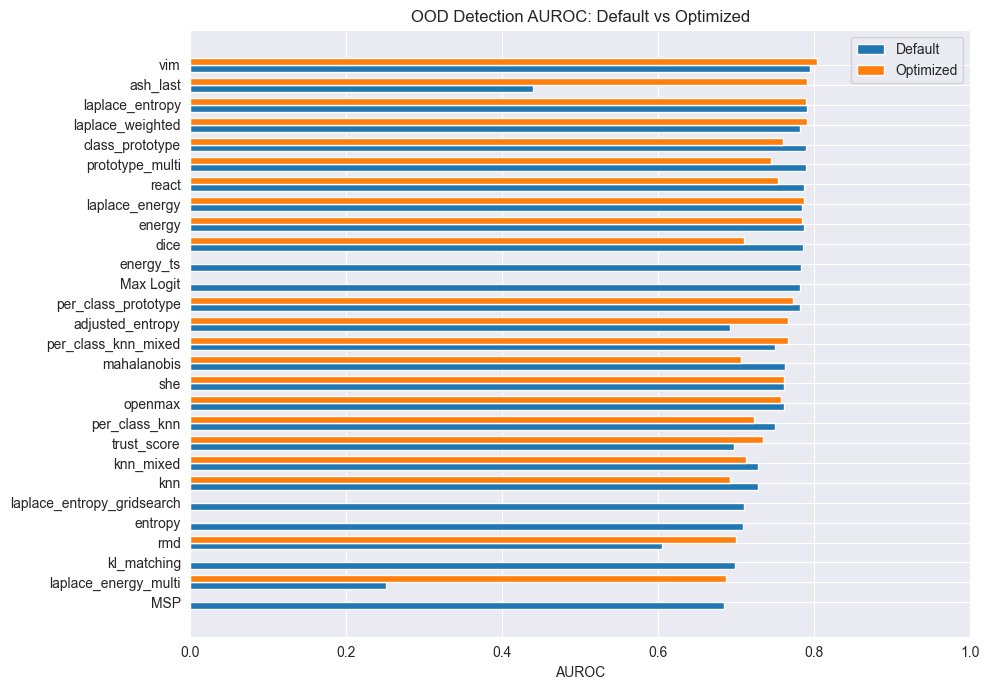

In [19]:
# python
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _extract_auroc(res):
    """
    Robust AUROC extractor: always returns (mean, se) where each is a float or np.nan.
    """
    if res is None:
        return (np.nan, np.nan)

    try:
        # common keys
        for k in ("auroc", "auroc_mean", "roc_auc", "auroc_ood", "auroc_score"):
            if k in res:
                mean = res.get(k)
                std = res.get(k + "_std", np.nan)

                # list-like per-run values
                if isinstance(mean, (list, tuple, np.ndarray)):
                    arr = np.array(mean, dtype=float)
                    if arr.size == 0:
                        return (np.nan, np.nan)
                    mean_v = float(np.nanmean(arr))
                    se_v = float(np.nanstd(arr) / np.sqrt(arr.size))
                    return (mean_v, se_v)

                # scalar mean
                try:
                    mean_v = float(mean)
                except Exception:
                    return (np.nan, np.nan)

                # try to parse std / se
                try:
                    se_v = float(std)
                except Exception:
                    se_v = np.nan

                return (mean_v, se_v)

        # per_run structure
        if "per_run" in res and isinstance(res["per_run"], list):
            arr = []
            for r in res["per_run"]:
                for cand in ("auroc", "roc_auc", "auroc_ood"):
                    if cand in r:
                        try:
                            arr.append(float(r[cand]))
                        except Exception:
                            pass
                        break
            if arr:
                arr = np.array(arr, dtype=float)
                return (float(arr.mean()), float(arr.std() / np.sqrt(arr.size)))
            return (np.nan, np.nan)

        # nested metrics dict
        if "metrics" in res and isinstance(res["metrics"], dict):
            return _extract_auroc(res["metrics"])

    except Exception:
        return (np.nan, np.nan)

    return (np.nan, np.nan)


# adjust these if different in your notebook; `base_results_dir` and `detectors` should already be defined
results = []
for det in detectors:
    path_default = os.path.join(base_results_dir, det, "eval_results_ood.json")
    path_best = os.path.join(base_results_dir, det, "eval_results_ood_best.json")

    res_default = None
    res_best = None
    if os.path.exists(path_default):
        try:
            with open(path_default, "r", encoding="utf-8") as f:
                res_default = json.load(f)
        except Exception:
            res_default = None
    if os.path.exists(path_best):
        try:
            with open(path_best, "r", encoding="utf-8") as f:
                res_best = json.load(f)
        except Exception:
            res_best = None

    mean_def, se_def = _extract_auroc(res_default)
    mean_best, se_best = _extract_auroc(res_best)

    results.append({
        "Detector": det,
        "Default_AUROC": mean_def,
        "Default_SE": se_def,
        "Optimized_AUROC": mean_best,
        "Optimized_SE": se_best,
    })

df = pd.DataFrame(results).set_index("Detector")

# ensure numeric columns (replace nested structures with NaN)
for col in ["Default_AUROC", "Optimized_AUROC", "Default_SE", "Optimized_SE"]:
    df[col] = pd.to_numeric(df[col].apply(lambda x: np.nan if isinstance(x, (list, tuple)) else x), errors="coerce")

# sort by best available AUROC
df["Max_AUROC"] = df[["Default_AUROC", "Optimized_AUROC"]].max(axis=1)
df = df.sort_values("Max_AUROC", ascending=True)  # ascending -> best at top for horizontal bar

# plotting
fig, ax = plt.subplots(figsize=(10, max(6, 0.25 * len(df))))
y = np.arange(len(df))
height = 0.35

ax.barh(y - height/2, df["Default_AUROC"].values, height, xerr=df["Default_SE"].values, label="Default", capsize=3)
ax.barh(y + height/2, df["Optimized_AUROC"].values, height, xerr=df["Optimized_SE"].values, label="Optimized", capsize=3)

ax.set_yticks(y)
ax.set_yticklabels(df.index)
ax.set_xlabel("AUROC")
ax.set_title("OOD Detection AUROC: Default vs Optimized")
ax.legend()
ax.set_xlim(0.0, 1.0)  # AUROC in [0,1]
plt.tight_layout()

# save to figures folder if exists (matches earlier notebook layout)
figure_path = os.path.join(current_path, "experiment_files", "export", "fig", "comparision_unsupervised", dataset, getattr(dataset_info, "transform_seq_name", "default"))
os.makedirs(figure_path, exist_ok=True)
plt.savefig(os.path.join(figure_path, "comparision_detectors_auroc.png"), dpi=200)

In [20]:
#iterate over the detectors and print default and best parameters
for detector in ["rmd_individual"]:
    detector_dir = os.path.join(base_results_dir, detector)
    params_path = os.path.join(detector_dir, "best_params.json")
    if os.path.exists(params_path):
        with open(params_path, "r") as f:
            best_params = json.load(f)
        print(f"\n=== Detector: {detector} ===")
        print("Best Parameters:")
        for k, v in best_params.items():
            print(f"  {k}: {v}")
    else:
        print(f"\n=== Detector: {detector} ===")
        print("No optimized parameters found.")
    #print default parameters
    default_params = get_default_ood_params(detector)
    print("Default Parameters:")
    for k, v in default_params.items():
        print(f"  {k}: {v}")


=== Detector: rmd_individual ===
Best Parameters:
  layer_indices: [0]
  reducer_name: None
  eps: 0
  shared_covariance: False
  aggregator_kind: linear
  scaler: none
  freeze_subs: True
  lr: 0.0008888448124704534
  epochs: 154
  use_correct_only: True
  use_layer_0: 1
  use_layer_1: 0
  use_layer_2: 0
  mahalanobis_eps: 0
  cov_mode: diag
  global_cov_mode: None
Default Parameters:
  reducer_name: None
  eps: 0
  shared_covariance: False
  aggregator_kind: linear
  scaler: none
  freeze_subs: True
  lr: 0.01
  epochs: 250
  use_correct_only: False
  layer_indices: [0]
  use_layer_0: 1
  mahalanobis_eps: 0
  cov_mode: diag
  global_cov_mode: full


In [21]:
import os
import json
import numpy as np
import pandas as pd

# === LOAD RESULTS ===
def load_metrics(result_dir, detectors):
    results = {}
    for det in detectors:
        eval_path = os.path.join(result_dir, det, "eval_results.json")
        eval_path_default = os.path.join(result_dir, det, "eval_results_default.json")
        print(f"Loading {eval_path} and {eval_path_default}...")

        # Initialize metrics with NaN
        metrics_data = {
            "accuracy_mean_optimized": np.nan,
            "accuracy_std_optimized": np.nan,
            "accuracy_mean_default": np.nan,
            "accuracy_std_default": np.nan,
            "accuracy_se_optimized": np.nan,
            "accuracy_se_default": np.nan,
        }

        # Load optimized results if file exists
        if os.path.exists(eval_path):
            with open(eval_path, "r") as f:
                data = json.load(f)
            metrics_data["accuracy_mean_optimized"] = data.get("accuracy_mean", np.nan)
            metrics_data["accuracy_std_optimized"] = data.get("accuracy_std", np.nan)
            metrics_data["accuracy_se_optimized"] = data.get("accuracy_se", np.nan)

        # Load default results if file exists
        if os.path.exists(eval_path_default):
            with open(eval_path_default, "r") as f:
                data_default = json.load(f)
            metrics_data["accuracy_mean_default"] = data_default.get("accuracy_mean", np.nan)
            metrics_data["accuracy_std_default"] = data_default.get("accuracy_std", np.nan)
            metrics_data["accuracy_se_default"] = data_default.get("accuracy_se", np.nan)

        results[det] = metrics_data

    return results

# Example usage
metrics = load_metrics(base_results_dir, detectors)

# === CREATE COMPARISON TABLE ===
comparison_data = []
for det in detectors:
    m = metrics[det]
    comparison_data.append({
        "Detector": det,
        "Optimized_Accuracy": m["accuracy_mean_optimized"],
        "Optimized_Std": m["accuracy_std_optimized"],
        "Default_Accuracy": m["accuracy_mean_default"],
        "Default_Std": m["accuracy_std_default"],
        "Optimized_SE": m["accuracy_se_optimized"],
        "Default_SE": m["accuracy_se_default"],
    })

df_compare = pd.DataFrame(comparison_data)
print("\n=== OOD Detector Comparison ===")
print(df_compare.to_string(index=False))


Loading C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\comparison_unsupervised\tu_berlin\bi_lstm\biggermnist_default\knn\eval_results.json and C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\comparison_unsupervised\tu_berlin\bi_lstm\biggermnist_default\knn\eval_results_default.json...
Loading C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\comparison_unsupervised\tu_berlin\bi_lstm\biggermnist_default\per_class_knn\eval_results.json and C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\comparison_unsupervised\tu_berlin\bi_lstm\biggermnist_default\per_class_knn\eval_results_default.json...
Loading C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\comparison_unsupervised\tu_berlin\bi_lstm\biggermnist_default\knn_mixed\eval_results.json and C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\comparison_unsupervise

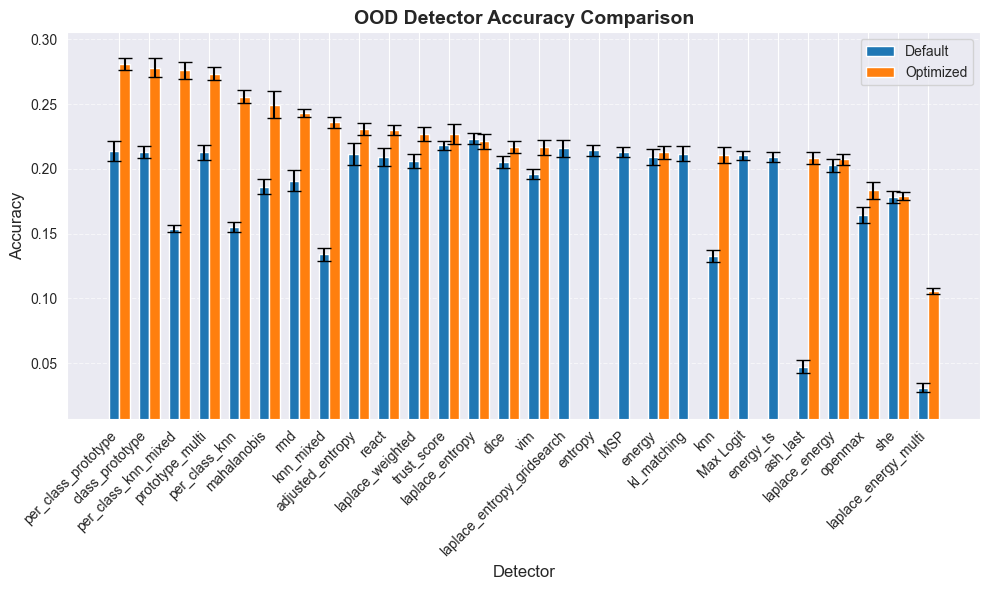

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming df_compare is already defined
df_plot = df_compare.assign(
    Max_Accuracy=df_compare[["Default_Accuracy", "Optimized_Accuracy"]].max(axis=1)
).sort_values("Max_Accuracy", ascending=False)

x = np.arange(len(df_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(
    x - width/2,
    df_plot["Default_Accuracy"],
    width,
    yerr=df_plot["Default_Std"],
    label="Default",
    capsize=5,
)

bars2 = ax.bar(
    x + width/2,
    df_plot["Optimized_Accuracy"],
    width,
    yerr=df_plot["Optimized_Std"],
    label="Optimized",
    capsize=5,
)

ax.set_xlabel("Detector", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("OOD Detector Accuracy Comparison", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(df_plot["Detector"], rotation=45, ha="right")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.6)

# === Zoom in Y-axis to focus on differences ===
y_min = min(df_plot[["Default_Accuracy", "Optimized_Accuracy"]].min().min(),
            (df_plot[["Default_Accuracy", "Optimized_Accuracy"]].min().min() -
             df_plot[["Default_Std", "Optimized_Std"]].max().max()))
y_max = max(df_plot[["Default_Accuracy", "Optimized_Accuracy"]].max().max(),
            (df_plot[["Default_Accuracy", "Optimized_Accuracy"]].max().max() +
             df_plot[["Default_Std", "Optimized_Std"]].max().max()))

# Add a small margin for visual breathing room
margin = (y_max - y_min) * 0.05
ax.set_ylim(y_min - margin, y_max + margin)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        #ax.text(bar.get_x() + bar.get_width()/2, height + 0.002, f"{height:.3f}",
        #        ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


In [23]:
from utils.eval.vis import plt_setup_latex

W = plt_setup_latex()

In [24]:
name_map = {
    "single_rmd": "1L-RMD",
    "single_mahalanobis": "1L-MD",
    "rmd": "RMD",
    "mahalanobis": "MD",
    "knn_mixed_faiss": "KNN Mixed (Faiss)",
    "knn_mixed": "KNN Mixed",
    "nn_guided_one": "NN-Guided (1)",

    "knn": "KNN",
    "per_class_knn_mixed": "P.C. KNN Mixed",
    "per_class_knn": "P.C. KNN",
    "knn_itf": "KNN-ITF",

    "trust_score": "Trust Score",
    "vim": "VIM",

    "per_class_prototype": "P.C. Prototype",
    "prototype_multi": "Prototype (multi)",
    "class_prototype": "Prototype",

    "kl_matching": "KL-Matching",

    "adjusted_entropy": "Adj. Entropy",
    "laplace_entropy": "Lapl. Entropy",
    "laplace_entropy_gridsearch": "Lapl. Entropy (GS)",
    "react_all": "ReAct (All)",
    "entropy": "Entropy",
    "laplace_weighted": "Lapl. Weighted",

    "react": "ReAct",
    "dice": "DICE",
    "laplace_mi": "Lapl. MI",

    # **Your specified preferred naming**
    "nn_guided": "NN-Guidance",
    "ash": "ASH",
    "openmax": "Openmax",
    "energy_ts": "Energy T. Scale",
    "energy": "Energy",
    "laplace_energy": "Lapl. Energy",
    "mahalanobis_individual": "MD-Diag",
    "single_rmd_individual": "1L-RMD-Diag",
    "single_mahalanobis_individual": "1L-MD-Diag",
    "she": "SHE",
    "rmd_individual": "RMD-Diag",
}




In [25]:
figure_path = os.path.join(current_path,"experiment_files","export","fig","comparision_unsupervised",dataset,transform_name)
if not os.path.exists(figure_path):
    os.makedirs(figure_path)

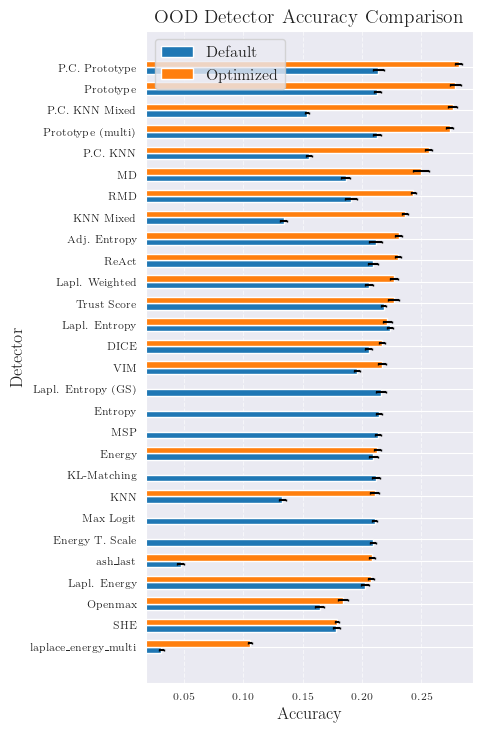

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare and rename detectors
df_plot = df_compare.assign(
    Max_Accuracy=df_compare[["Default_Accuracy", "Optimized_Accuracy"]].max(axis=1)
).sort_values("Max_Accuracy", ascending=True)   # ascending → best at top

df_plot["Detector"] = df_plot["Detector"].replace(name_map)

y = np.arange(len(df_plot))
height = 0.3

fig, ax = plt.subplots(figsize=(W, W*1.5))

bars1 = ax.barh(
    y - height/2,
    df_plot["Default_Accuracy"],
    height,
    xerr=df_plot["Default_SE"]*1.96,
    label="Default",
    capsize=1,
)

bars2 = ax.barh(
    y + height/2,
    df_plot["Optimized_Accuracy"],
    height,
    xerr=df_plot["Optimized_SE"]*1.96,
    label="Optimized",
    capsize=1,
)

ax.set_ylabel("Detector", fontsize=12)
ax.set_xlabel("Accuracy", fontsize=12)
ax.set_title("OOD Detector Accuracy Comparison", fontsize=14, fontweight="bold")
ax.set_yticks(y)
ax.set_yticklabels(df_plot["Detector"])
ax.legend()
ax.grid(axis="x", linestyle="--", alpha=0.6)

# === Zoom in X-axis to focus on differences ===
x_min = min(df_plot["Default_Accuracy"].min(), df_plot["Optimized_Accuracy"].min())
x_max = max(df_plot["Default_Accuracy"].max(), df_plot["Optimized_Accuracy"].max())
margin = (x_max - x_min) * 0.05
ax.set_xlim(x_min - margin, x_max + margin)

figure_path = os.path.join(current_path,"experiment_files","export","fig","comparision_unsupervised",dataset,transform_name)
if not os.path.exists(figure_path):
    os.makedirs(figure_path)
plt.tight_layout()   # <--- move this before savefig
plt.savefig(os.path.join(figure_path, "comparision_detectors.pdf"))
plt.savefig(os.path.join(figure_path, "comparision_detectors.pgf"))
plt.tight_layout()
plt.show()


C:\Users\Lindner\AppData\Local\Temp\ipykernel_3904\3357365026.py:51: RuntimeWarning: All-NaN axis encountered
  np.nanmin([x_comb.min(), y_comb.min()]) if np.isfinite(x_comb).any() else 0,
C:\Users\Lindner\AppData\Local\Temp\ipykernel_3904\3357365026.py:52: RuntimeWarning: All-NaN axis encountered
  np.nanmax([x_comb.max(), y_comb.max()]) if np.isfinite(x_comb).any() else 1,


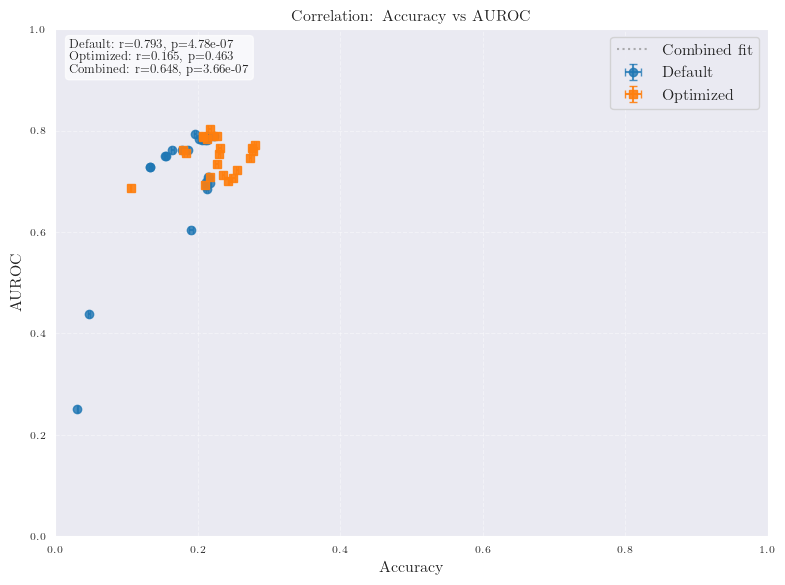

In [27]:
# python
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# merge AUROC (df) and accuracy table (df_compare)
auroc_df = df.reset_index()[["Detector", "Default_AUROC", "Default_SE", "Optimized_AUROC", "Optimized_SE"]].rename(
    columns={"Default_SE": "Default_AUROC_SE", "Optimized_SE": "Optimized_AUROC_SE"}
)
merged = df_compare.merge(auroc_df, on="Detector", how="inner")

# helper to compute pearson r and fit linear regression
def corr_and_fit(x, y):
    # drop NaNs
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return (np.nan, np.nan, None)
    r, p = stats.pearsonr(x[mask], y[mask])
    coef = np.polyfit(x[mask], y[mask], 1)
    fit_fn = np.poly1d(coef)
    return r, p, fit_fn

# Default
x_def = merged["Default_Accuracy"].to_numpy()
y_def = merged["Default_AUROC"].to_numpy()
r_def, p_def, fit_def = corr_and_fit(x_def, y_def)

# Optimized
x_opt = merged["Optimized_Accuracy"].to_numpy()
y_opt = merged["Optimized_AUROC"].to_numpy()
r_opt, p_opt, fit_opt = corr_and_fit(x_opt, y_opt)

# Combined (both points)
x_comb = np.concatenate([x_def, x_opt])
y_comb = np.concatenate([y_def, y_opt])
r_comb, p_comb, fit_comb = corr_and_fit(x_comb, y_comb)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
# errorbars: x = accuracy ± Accuracy_SE, y = auroc ± AUROC_SE
ax.errorbar(merged["Default_Accuracy"], merged["Default_AUROC"],
            xerr=merged.get("Default_SE"), yerr=merged.get("Default_AUROC_SE"),
            fmt='o', label="Default", alpha=0.8, capsize=3)
ax.errorbar(merged["Optimized_Accuracy"], merged["Optimized_AUROC"],
            xerr=merged.get("Optimized_SE"), yerr=merged.get("Optimized_AUROC_SE"),
            fmt='s', label="Optimized", alpha=0.9, capsize=3)

# regression lines
xs = np.linspace(
    np.nanmin([x_comb.min(), y_comb.min()]) if np.isfinite(x_comb).any() else 0,
    np.nanmax([x_comb.max(), y_comb.max()]) if np.isfinite(x_comb).any() else 1,
    100
)
if fit_def is not None:
    ax.plot(xs, fit_def(xs), color='C0', linestyle='--', alpha=0.6)
if fit_opt is not None:
    ax.plot(xs, fit_opt(xs), color='C1', linestyle='--', alpha=0.6)
if fit_comb is not None:
    ax.plot(xs, fit_comb(xs), color='grey', linestyle=':', alpha=0.6, label='Combined fit')

ax.set_xlabel("Accuracy")
ax.set_ylabel("AUROC")
ax.set_title("Correlation: Accuracy vs AUROC")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.grid(True, linestyle='--', alpha=0.4)

# annotate correlations
txt = (
    f"Default: r={r_def:.3f}, p={p_def:.3g}\n"
    f"Optimized: r={r_opt:.3f}, p={p_opt:.3g}\n"
    f"Combined: r={r_comb:.3f}, p={p_comb:.3g}"
)
ax.text(0.02, 0.98, txt, transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

ax.legend()
plt.tight_layout()

# save (optional)
figure_path = os.path.join(current_path, "experiment_files", "export", "fig", "comparision_unsupervised", dataset, getattr(dataset_info, "transform_seq_name", "default"))
os.makedirs(figure_path, exist_ok=True)
plt.savefig(os.path.join(figure_path, "accuracy_vs_auroc.png"), dpi=200)
plt.show()

In [28]:
#print default and best hyperparametrs for she dice and ash
for detector in ["she","dice","ash_last","nn_guided"]:
    detector_dir = os.path.join(base_results_dir, detector)
    params_path = os.path.join(detector_dir, "best_params.json")
    if os.path.exists(params_path):
        with open(params_path, "r") as f:
            best_params = json.load(f)
        print(f"\n=== Detector: {detector} ===")
        print("Best Parameters:")
        for k, v in best_params.items():
            print(f"  {k}: {v}")
    else:
        print(f"\n=== Detector: {detector} ===")
        print("No optimized parameters found.")
    #print default parameters
    default_params = get_default_ood_params(detector)
    print("Default Parameters:")
    for k, v in default_params.items():
        print(f"  {k}: {v}")


=== Detector: she ===
Best Parameters:
  layer_index: 0
  reducer_name: None
  penalize_missmatches: False
  split_b: 0.0
Default Parameters:
  layer_index: 0
  reducer_name: None
  penalize_missmatches: True
  split_b: 0.0

=== Detector: dice ===
Best Parameters:
  percentile: 0.880549728953559
  split_b: 0.0
  confidence_type: entropy
Default Parameters:
  percentile: 0.1
  split_b: 0.0
  confidence_type: energy

=== Detector: ash_last ===
Best Parameters:
  variant: ash-p
  percentile: 0.42801129259398873
  layer_index: 0
  index_logits: None
  confidence_type: energy
  use_feature_confidence: False
Default Parameters:
  percentile: 0.65
  variant: ash-b
  layer_index: 0
  index_logits: None
  confidence_type: energy
  use_feature_confidence: False

=== Detector: nn_guided ===
Best Parameters:
  k: 15
  base_confidence: entropy
  dtype: float32
  layer_index: 1
  reducer_name: None
  split_b: 0.0
  use_correct_only: False
Default Parameters:
  k: 3
  base_confidence: energy
  dtype

In [29]:

#mahalanobis is also far behind what i expcet maybe reimplemnt

In [30]:
import time
import os
import json
import torch
import numpy as np

# ---------------------------------------------
# SPEED TEST (compatible with TransformationProblem)
# ---------------------------------------------
speedtest_batches = 15
speedtest_results_dir = os.path.join(base_results_dir, "speedtests")
os.makedirs(speedtest_results_dir, exist_ok=True)

print("\n=== Running speed tests for detectors (fixed) ===")
for detector in detectors:
    if detector == "laplace_entropy_gridsearch":
        print(f"\n[SpeedTest] Skipping detector {detector} (too expensive).")
        continue
    print(f"\n[SpeedTest] Detector: {detector}")
    detector_dir = os.path.join(base_results_dir, detector)
    speedtest_path = os.path.join(speedtest_results_dir, f"{detector}_speed.json")
    if os.path.exists(speedtest_path):
        print(f"[SpeedTest] Found cached result at {speedtest_path}, skipping measurement.")
        continue

    # Pick params (optimized if available)
    params_path = os.path.join(detector_dir, "best_params.json")
    if os.path.exists(params_path):
        with open(params_path, "r") as f:
            best_params = json.load(f)
        print(f"[SpeedTest] Using optimized params.")
    else:
        best_params = get_default_ood_params(detector)
        print(f"[SpeedTest] Using default params.")

    # Try loading any saved model states
    best_model_path_prefix = os.path.join(detector_dir, "best_model")
    loaded_model_params = []
    idx = 0
    while os.path.exists(f"{best_model_path_prefix}_{idx}.pt"):
        loaded_model_params.append(torch.load(f"{best_model_path_prefix}_{idx}.pt", map_location=device))
        idx += 1

    # Build OOD problem
    final_kwargs = {
        "model": model,
        "train_cache": train_cache,
        "transform_seq": transform_seq_arg,
        "dataset_info": dataset_info,
        "architecture": architecture,
        "device": str(device),
        "val_id_loader": val_loader_preshuffled_in_dist,
        "val_ood_loader": val_loader_transformed_preshuffled,
    }
    if loaded_model_params:
        final_kwargs["model_params"] = loaded_model_params
    problem = create_ood_problem(detector, best_params, **final_kwargs)

    model.eval().to(device)
    torch.cuda.empty_cache()
    test_iter = iter(test_loader_transformed)

    times = []
    total_samples = 0
    with torch.no_grad():
        for batch_idx in range(speedtest_batches):
            try:
                data, _ = next(test_iter)
            except StopIteration:
                break
            data = data.to(device)
            total_samples += data.size(0)

            # Timing start
            torch.cuda.synchronize(device) if torch.cuda.is_available() else None
            start_time = time.perf_counter()

            # Simulate detector inference (similar to evaluate_confidence_and_search)
            res = optimizer_search_eval.optimize(problem, data, y=None)
            best_param = res[0] if isinstance(res, tuple) and len(res) >= 1 else res
            x_trans = problem.transform(data, best_param)
            _ = model(x_trans)

            # Timing end
            torch.cuda.synchronize(device) if torch.cuda.is_available() else None
            elapsed = time.perf_counter() - start_time

            # Skip first batch from timing
            if batch_idx > 0:
                times.append(elapsed)
                print(f"[SpeedTest] Batch {batch_idx+1}: {elapsed:.4f}s")
            else:
                print(f"[SpeedTest] Batch {batch_idx+1} (warmup, ignored): {elapsed:.4f}s")

    # Summarize
    avg_batch_time = np.mean(times)
    avg_sample_time = avg_batch_time / (total_samples / len(times))
    result = {
        "detector": detector,
        "batches_tested": len(times),
        "avg_time_per_batch_sec": avg_batch_time,
        "avg_time_per_sample_sec": avg_sample_time,
        "device": str(device),
        "batch_size": dataset_info.batch_size,
    }
    with open(speedtest_path, "w") as f:
        json.dump(result, f, indent=2)
    print(f"[SpeedTest] Saved results to {speedtest_path}")
    print(f"[SpeedTest] Avg: {avg_batch_time:.4f}s/batch ({avg_sample_time*1e3:.3f} ms/sample)")

print("\nAll speed tests completed successfully.")



=== Running speed tests for detectors (fixed) ===

[SpeedTest] Detector: knn
[SpeedTest] Found cached result at C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\comparison_unsupervised\tu_berlin\bi_lstm\biggermnist_default\speedtests\knn_speed.json, skipping measurement.

[SpeedTest] Detector: per_class_knn
[SpeedTest] Found cached result at C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\comparison_unsupervised\tu_berlin\bi_lstm\biggermnist_default\speedtests\per_class_knn_speed.json, skipping measurement.

[SpeedTest] Detector: knn_mixed
[SpeedTest] Found cached result at C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\comparison_unsupervised\tu_berlin\bi_lstm\biggermnist_default\speedtests\knn_mixed_speed.json, skipping measurement.

[SpeedTest] Detector: per_class_knn_mixed
[SpeedTest] Found cached result at C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\comp


=== Plotting speed test results ===
[Plot] Warning: No speed test result found for laplace_entropy_gridsearch


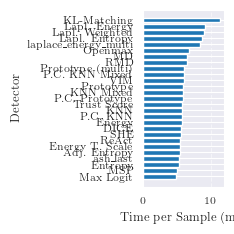

✅ Saved speed comparison plot to C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\comparison_unsupervised\tu_berlin\bi_lstm\biggermnist_default\speedtests\detector_speed_comparison.pdf

=== Speed Summary (sorted by ms/sample) ===
Max Logit                4.848 ms/sample   (0.6649 s/batch)
MSP                      4.951 ms/sample   (0.6791 s/batch)
Entropy                  5.216 ms/sample   (0.6677 s/batch)
ash_last                 5.340 ms/sample   (0.6835 s/batch)
Adj. Entropy             5.400 ms/sample   (0.6912 s/batch)
Energy T. Scale          5.438 ms/sample   (0.6960 s/batch)
ReAct                    5.487 ms/sample   (0.7023 s/batch)
SHE                      5.623 ms/sample   (0.7197 s/batch)
DICE                     5.628 ms/sample   (0.7204 s/batch)
Energy                   5.677 ms/sample   (0.7266 s/batch)
P.C. KNN                 5.740 ms/sample   (0.7347 s/batch)
KNN                      5.755 ms/sample   (0.7367 s/batch)
Trust Score         

In [31]:
import matplotlib.pyplot as plt

# ---------------------------------------------
# PLOT SPEED TEST RESULTS
# ---------------------------------------------
print("\n=== Plotting speed test results ===")

speed_results = []
for detector in detectors:
    speedtest_path = os.path.join(speedtest_results_dir, f"{detector}_speed.json")
    if os.path.exists(speedtest_path):
        with open(speedtest_path, "r") as f:
            data = json.load(f)
            speed_results.append(data)
    else:
        print(f"[Plot] Warning: No speed test result found for {detector}")

if not speed_results:
    print("No speed test results found. Skipping plot.")
else:
    detectors_plot = [r["detector"] for r in speed_results]



    per_sample_ms = [r["avg_time_per_sample_sec"] * 1000 for r in speed_results]
    per_batch_s = [r["avg_time_per_batch_sec"] for r in speed_results]

    # Sort by speed (ascending)
    sort_idx = np.argsort(per_sample_ms)
    detectors_plot = [detectors_plot[i] for i in sort_idx]
    per_sample_ms = [per_sample_ms[i] for i in sort_idx]
    per_batch_s = [per_batch_s[i] for i in sort_idx]

    #replace the detector name
    detectors_plot = [name_map.get(name, name) for name in detectors_plot]

    plt.figure(figsize=(W/2, W/2))
    plt.barh(detectors_plot, per_sample_ms)
    plt.xlabel("Time per Sample (ms)",fontsize=9)
    plt.ylabel("Detector",fontsize=9)
    plt.grid(axis="x", linestyle="--", alpha=0.5)
    plt.tight_layout()

    plot_path = os.path.join(speedtest_results_dir, "detector_speed_comparison.pdf")

    plt.savefig(plot_path, dpi=200)
    plt.show()

    print(f"✅ Saved speed comparison plot to {plot_path}")

    # Optional: print a text summary
    print("\n=== Speed Summary (sorted by ms/sample) ===")
    for d, t_s, t_b in zip(detectors_plot, per_sample_ms, per_batch_s):
        print(f"{d:20s}  {t_s:8.3f} ms/sample   ({t_b:.4f} s/batch)")



=== Plotting speed test results for multiple datasets ===
Loaded 26 speed test results for bigger_mnist
Loaded 26 speed test results for bigger_emnist
Loaded 23 speed test results for coil100
Loaded 27 speed test results for tu_berlin
Loaded 27 speed test results for modelnet10


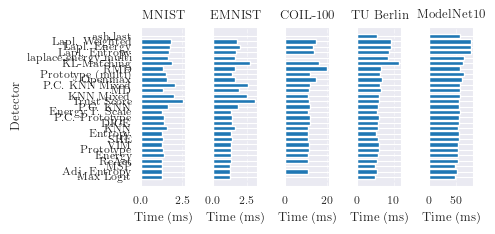

✅ Saved combined speed comparison plot to C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\comparison_unsupervised\tu_berlin\bi_lstm\biggermnist_default\..\detector_speed_comparison_all_datasets.pdf


In [32]:
import matplotlib.pyplot as plt
import numpy as np
import os
import json

# ---------------------------------------------
# PLOT SPEED TEST RESULTS FOR MULTIPLE DATASETS
# ---------------------------------------------
print("\n=== Plotting speed test results for multiple datasets ===")

datasets_to_plot = ["bigger_mnist", "bigger_emnist", "coil100", "tu_berlin", "modelnet10"]
dataset_labels = ["MNIST", "EMNIST", "COIL-100", "TU Berlin", "ModelNet10"]

# Collect speed results for all datasets
all_speed_data = {}
for ds in datasets_to_plot:
    # Get dataset-specific transform name
    ds_info = get_dataset_info(ds)
    ds_transform_name = getattr(ds_info, "transform_seq_name", "default")

    speed_dir = os.path.join(
        current_path,
        "experiment_files",
        "results",
        "comparison_unsupervised",
        ds,
        default_architecutre_mapping[ds],
        ds_transform_name,
        "speedtests"
    )

    speed_results = []
    for detector in detectors:
        speedtest_path = os.path.join(speed_dir, f"{detector}_speed.json")
        if os.path.exists(speedtest_path):
            with open(speedtest_path, "r") as f:
                data = json.load(f)
                speed_results.append(data)

    all_speed_data[ds] = speed_results
    print(f"Loaded {len(speed_results)} speed test results for {ds}")

# Determine common detector order (sorted by average speed across all datasets)
detector_speeds = {}
for ds, results in all_speed_data.items():
    for r in results:
        det = r["detector"]
        speed = r["avg_time_per_sample_sec"] * 1000
        if det not in detector_speeds:
            detector_speeds[det] = []
        detector_speeds[det].append(speed)

# Calculate average speed per detector
avg_speeds = {det: np.mean(speeds) for det, speeds in detector_speeds.items()}
sorted_detectors = sorted(avg_speeds.keys(), key=lambda d: avg_speeds[d])
sorted_detector_names = [name_map.get(d, d) for d in sorted_detectors]

# Prepare data for plotting
plot_data = []
for ds in datasets_to_plot:
    per_sample_ms = []
    for det in sorted_detectors:
        # Find speed for this detector in this dataset
        speed = next(
            (r["avg_time_per_sample_sec"] * 1000
             for r in all_speed_data[ds] if r["detector"] == det),
            np.nan
        )
        per_sample_ms.append(speed)
    plot_data.append(per_sample_ms)

# Create plots
fig, axes = plt.subplots(1, len(datasets_to_plot), figsize=(W, W/2), sharey=True)

for idx, (ax, ds_label, data) in enumerate(zip(axes, dataset_labels, plot_data)):
    ax.barh(sorted_detector_names, data)
    ax.set_xlabel("Time (ms)", fontsize=9)
    ax.set_title(ds_label, fontsize=9)
    ax.grid(axis="x", linestyle="--", alpha=0.5)

    # Only show y-labels on the first plot
    if idx == 0:
        ax.set_ylabel("Detector", fontsize=9)

    ax.tick_params(labelsize=8)

plt.tight_layout()

plot_path = os.path.join(base_results_dir, "..", "detector_speed_comparison_all_datasets.pdf")
plt.savefig(plot_path, dpi=200)
plt.savefig(plot_path.replace(".pdf", ".pgf"))
plt.show()

print(f"✅ Saved combined speed comparison plot to {plot_path}")

In [33]:
import os
import json
import numpy as np
import pandas as pd

# ---------------------------------------------
# CREATE LATEX TABLE WITH RELATIVE TIMES
# ---------------------------------------------
print("\n=== Creating LaTeX table with relative times ===")

datasets_to_plot = ["bigger_mnist", "bigger_emnist", "coil100", "tu_berlin", "modelnet10"]
dataset_labels = ["Big MNIST", "Big EMNIST", "COIL-100", "TU Berlin", "ModelNet10"]

# Collect speed results for all datasets
all_speed_data = {}
for ds in datasets_to_plot:
    ds_info = get_dataset_info(ds)
    ds_transform_name = getattr(ds_info, "transform_seq_name", "default")

    speed_dir = os.path.join(
        current_path,
        "experiment_files",
        "results",
        "comparison_unsupervised",
        ds,
        default_architecutre_mapping[ds],
        ds_transform_name,
        "speedtests"
    )

    speed_results = []
    for detector in detectors:
        speedtest_path = os.path.join(speed_dir, f"{detector}_speed.json")
        if os.path.exists(speedtest_path):
            with open(speedtest_path, "r") as f:
                data = json.load(f)
                speed_results.append(data)

    all_speed_data[ds] = speed_results

# Build DataFrame with relative times
rows = []
for ds, ds_label in zip(datasets_to_plot, dataset_labels):
    # Find energy baseline time for this dataset
    energy_time = next(
        (r["avg_time_per_sample_sec"] * 1000
         for r in all_speed_data[ds] if r["detector"] == "energy"),
        None
    )

    if energy_time is None:
        print(f"Warning: No energy baseline found for {ds}")
        continue

    for detector in detectors:
        det_time = next(
            (r["avg_time_per_sample_sec"] * 1000
             for r in all_speed_data[ds] if r["detector"] == detector),
            None
        )

        if det_time is not None:
            relative_time = det_time / energy_time
            rows.append({
                "Detector": name_map.get(detector, detector),
                "Dataset": ds_label,
                "Relative Time": relative_time
            })

df = pd.DataFrame(rows)

# Pivot to get detectors as rows, datasets as columns (maintaining order)
table = df.pivot(index="Detector", columns="Dataset", values="Relative Time")
# Reorder columns to match dataset_labels order
table = table[dataset_labels]

# Sort by average relative time
table["Average"] = table.mean(axis=1)
table = table.sort_values("Average")

# Format as LaTeX
latex_str = table.to_latex(
    float_format="%.2f",
    caption="Relative inference time compared to Energy baseline (Energy = 1.0)",
    label="tab:speed_comparison",
    escape=False
)

# Save to file
latex_path = os.path.join(base_results_dir, "..", "speed_comparison_relative.tex")
with open(latex_path, "w") as f:
    f.write(latex_str)

print(f"✅ Saved LaTeX table to {latex_path}")
print("\n" + latex_str)


=== Creating LaTeX table with relative times ===
✅ Saved LaTeX table to C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\results\comparison_unsupervised\tu_berlin\bi_lstm\biggermnist_default\..\speed_comparison_relative.tex

\begin{table}
\caption{Relative inference time compared to Energy baseline (Energy = 1.0)}
\label{tab:speed_comparison}
\begin{tabular}{lrrrrrr}
\toprule
Dataset & Big MNIST & Big EMNIST & COIL-100 & TU Berlin & ModelNet10 & Average \\
Detector &  &  &  &  &  &  \\
\midrule
Max Logit & 0.93 & 0.97 & NaN & 0.85 & 0.90 & 0.91 \\
MSP & 0.92 & 0.97 & NaN & 0.87 & 0.90 & 0.92 \\
Adj. Entropy & 0.94 & 0.98 & 1.00 & 0.95 & 0.94 & 0.96 \\
Entropy & 0.94 & 1.00 & 1.00 & 0.92 & 1.03 & 0.98 \\
ReAct & 0.94 & 1.02 & 1.00 & 0.97 & 0.98 & 0.98 \\
Energy T. Scale & 0.94 & 1.02 & 1.01 & 0.96 & 1.05 & 0.99 \\
ash_last & NaN & NaN & NaN & 0.94 & 1.06 & 1.00 \\
Energy & 1.00 & 1.00 & 1.00 & 1.00 & 1.00 & 1.00 \\
VIM & 0.93 & 1.00 & 1.04 & 1.06 & 0.99 & 1.00 \\


In [34]:
from confidence.control.split import PredictedSplitConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.model.single_pass import SinglePassConfidence
from utils.transformation_problem import TransformationProblem
from experiment_thesis.dataset_preperation.basic_networks import get_network_layer
from confidence.unsupervised.classic.SHE import SHETorchConfidence


layer,layer_io = get_network_layer(dataset_info, architecture,1, num_classes=None, num_rotations=8)

she_detector = SHETorchConfidence()
embeddings_t, final_t, classes_t = train_cache.__call__(layer, capture_modes=layer_io, flatten=True)

she_detector.fit(embeddings_t,classes_t).cuda()
dual_output_model = train_cache.make_wrapper(layer, capture_modes=layer_io, concat=False, flatten=True, reducer_select= None)
conf_split = PredictedSplitConfidence(she_detector, EnergyConfidence(), mult=False, b=params.get("split_b", 0.0))
conf_mod = SinglePassConfidence(dual_output_model, conf_split, index=1)


problem_she = TransformationProblem(
    confidence_module=conf_mod.cuda(),
    transform_sequence=transform_seq,
    max_batch_size = dataset_info.batch_size_search,
)


NameError: name 'params' is not defined